# Stage 6, Project: Fraud Detection

**Problem:** identify fraudulent credit card transactions among a huge volume of legitimate ones.

**Dataset:** Kaggle's classic Credit Card Fraud dataset — 284,807 European transactions from September 2013, 492 of them fraud. Features `V1`-`V28` are PCA-transformed (already anonymized/compressed for privacy, so you can't interpret them individually the way you could Titanic's `age` or `fare`), plus `Time` and `Amount` in their original form.

**This project is fundamentally about severe class imbalance** — 0.17% positive class, over 500x more legitimate transactions than fraudulent ones. Every technique here exists specifically to handle that.

New concepts: XGBoost (the industry-standard tabular algorithm), SMOTE (synthetic oversampling), and why PR-AUC becomes the metric that actually matters when ROC-AUC would tell a misleadingly rosy story.

## 1. Load and first look

Note: this file is ~98MB, so loading will take a few seconds — larger than anything you've worked with so far.

Guiding questions:
- Compute the exact class imbalance ratio. How does 0.17% compare to Titanic's ~38% or Telco's ~27%?
- `V1`-`V28` are already PCA components — given what you know about PCA from Stage 4, why would a bank release data this way instead of raw transaction details?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/nsethi31/Kaggle-Data-Credit-Card-Fraud-Detection/master/creditcard.csv"

# TODO: load with pd.read_csv(url) -- this will take a few seconds given the file size


df = pd.read_csv(url)


In [ ]:
# TODO: .info(), Class value_counts(), exact imbalance percentage

df.info()
classCount = df.value_counts("Class")
classFalse = classCount[0]
classTrue = classCount[1]
print(f"{classTrue / (classFalse+classTrue):.5f}")



0.00173


## 2. EDA

Guiding questions:
- Plot the distribution of `Amount` for fraud vs. non-fraud transactions separately. Do fraudulent transactions tend to be larger, smaller, or similar in size?
- `Time` is seconds elapsed since the first transaction in the dataset. Does fraud cluster at certain times, or is it spread evenly?
- Since `V1`-`V28` are anonymized, you can't interpret them individually yet — but you CAN check whether any of them separate the two classes well. Try plotting a couple of them (e.g., `V14`, `V17`) as histograms split by `Class`.

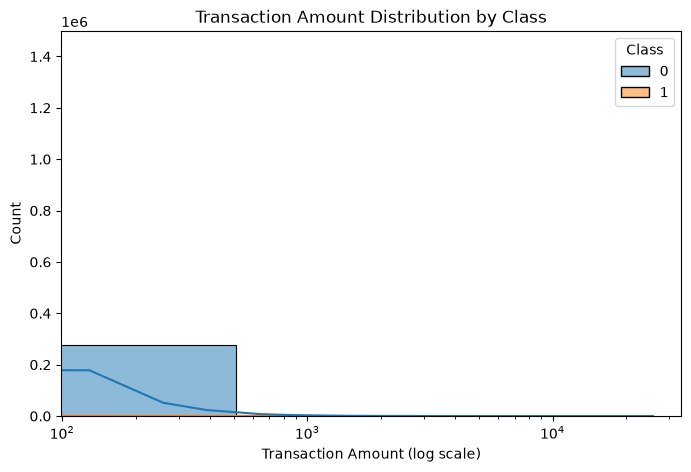

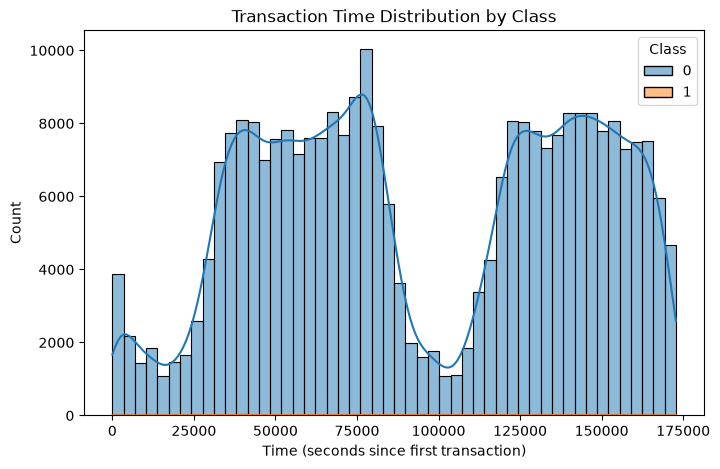

' \nplt.figure(figsize=(8, 5))\nsns.histplot(\n    data=df,\n    x="V14",\n    hue="Class",\n    kde=True\n)\nplt.title("V14 Distribution by Class")\nplt.show()\n\n\n\nplt.figure(figsize=(8, 5))\nsns.histplot(\n    data=df,\n    x="V17",\n    hue="Class",\n    kde=True\n)\nplt.title("V14 Distribution by Class")\nplt.show()\n\n'

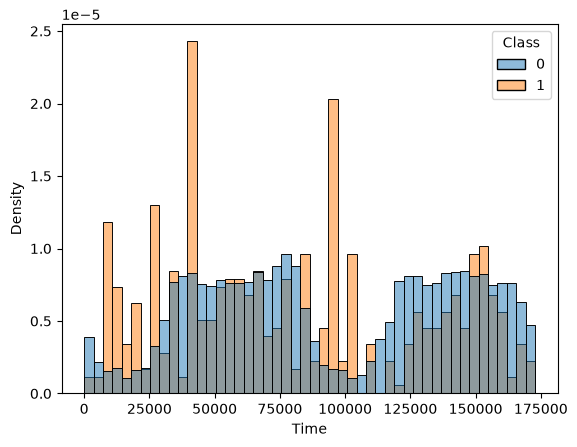

In [28]:
# TODO: Amount distribution by class, Time distribution by class, a couple V-column histograms split by class
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Amount",
    hue="Class",
    kde=True,
    bins=50
)

plt.xscale("log")
plt.title("Transaction Amount Distribution by Class")
plt.xlabel("Transaction Amount (log scale)")
plt.ylabel("Count")
plt.show()



plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Time",
    hue="Class",
    bins=50,
    kde=True
)

plt.title("Transaction Time Distribution by Class")
plt.xlabel("Time (seconds since first transaction)")
plt.ylabel("Count")
plt.show()


# Option 2: normalize both to density instead of raw count, on one shared plot
sns.histplot(data=df, x='Time', hue='Class', bins=48, stat='density', common_norm=False)


''' 
plt.figure(figsize=(8, 5))
sns.histplot(
    data=df,
    x="V14",
    hue="Class",
    kde=True
)
plt.title("V14 Distribution by Class")
plt.show()



plt.figure(figsize=(8, 5))
sns.histplot(
    data=df,
    x="V17",
    hue="Class",
    kde=True
)
plt.title("V14 Distribution by Class")
plt.show()

'''


## 3. Split and scale

`Amount` and `Time` are on very different scales than the PCA components (which are already roughly standardized by construction). Scale just those two.

Guiding question: with only 492 fraud cases total, why is a stratified split (not just random) absolutely essential here — more so than it was for Titanic?

In [75]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# TODO: split X/y (target is 'Class'), stratified train/val/test split,
# scale 'Amount' and 'Time' only (fit on train), leave V1-V28 as-is (already scaled)

# Split X/y
X = df.drop(columns=["Class"])
y = df["Class"]
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)


#Scale 'Amount' and 'Time'
scaler = StandardScaler()
features_to_scale = ["Time", "Amount"]

X_train = X_train.copy()
X_val = X_val.copy()
X_test = X_test.copy()

# Fit ONLY on training data
X_train[features_to_scale] = scaler.fit_transform(
    X_train[features_to_scale]
)

# Transform validation/test using the same scaler
X_val[features_to_scale] = scaler.transform(
    X_val[features_to_scale]
)

X_test[features_to_scale] = scaler.transform(
    X_test[features_to_scale]
)










## 4. Baseline

Given the imbalance ratio from Section 1, what would a majority-class-only model score on accuracy? Compute it — the number itself will make the point better than any explanation could.

This is also where you should decide: given this ratio, is accuracy even worth glancing at again for the rest of this project?

The majority-class baseline achieves approximately 99.83% accuracy by predicting every transaction as non-fraud. This demonstrates that accuracy is misleading for this highly imbalanced dataset. Because the goal is to detect the small number of fraudulent transactions, I will focus primarily on precision, recall, F1-score, and PR-AUC rather than accuracy.

In [76]:
# TODO: majority-class baseline accuracy
majority_class = y.value_counts().idxmax()

baseline_accuracy = (
    y.value_counts().max() / len(y)
)

print("Majority class:", majority_class)
print("Baseline accuracy:", baseline_accuracy)

Majority class: 0
Baseline accuracy: 0.9982725143693799


## 5. Train a first model — XGBoost, no imbalance handling yet

Train XGBoost on the raw, imbalanced training data first, with no special handling. You need to see how a model trained this way behaves before you understand why the fixes in Section 6 matter.

**Syntax note:** `XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)`. Conceptually similar to `RandomForestClassifier`, but instead of building independent trees and averaging them, XGBoost builds trees sequentially, where each new tree specifically targets the previous trees' mistakes (gradient boosting, from Stage 4). `learning_rate` controls how much each new tree is allowed to correct — smaller values need more trees but tend to generalize better.

In [103]:
from xgboost import XGBClassifier

# TODO: train XGBClassifier on the raw imbalanced X_train/y_train

xgb_raw = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

xgb_raw.fit(X_train, y_train)
y_pred = xgb_raw.predict(X_val)
y_pred_prob = xgb_raw.predict_proba(X_val)[:, 1]

print(y_pred_prob)




[2.1693510e-05 3.5942783e-05 2.4733377e-05 ... 5.0933089e-05 9.7717646e-05
 1.1876475e-04]


## 6. Evaluate the first model — and see the ROC-AUC trap firsthand

Compute BOTH ROC-AUC and PR-AUC (Stage 5 techniques) on this first model.

Guiding question, answer this from your actual numbers, not in the abstract: is ROC-AUC misleadingly high here compared to PR-AUC and recall? This is the exact scenario Stage 5's guiding questions warned you about — now you get to see it happen on a real, heavily imbalanced dataset instead of just reasoning about it hypothetically.

In [104]:
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)
# TODO: evaluate the raw-imbalanced-trained model on validation: confusion matrix, precision, recall, F1, ROC-AUC, PR-AUC
print(confusion_matrix(y_val, y_pred))
precision_xgb = ( precision_score(y_val, y_pred))
recall_xgb =(recall_score(y_val, y_pred))
f1_xgb =(f1_score(y_val, y_pred))
roc_auc_xgb =(roc_auc_score(y_val, y_pred_prob))
avg_precision_xgb =average_precision_score(y_val, y_pred_prob)



# Precision --  (Out of all predicted positives, how many are actually true) : TP/ TP+FP
# Recall --  (Out of all actual positives in the data, how many did the model find): TP/ (TP + FN)


[[42644     3]
 [   18    56]]


## 7. Handling imbalance, approach 1: class_weight

The simplest fix: tell the model to penalize mistakes on the minority class more heavily during training, rather than changing the data itself.

**Syntax note:** XGBoost's equivalent is `scale_pos_weight`, roughly `(number of negative samples) / (number of positive samples)`. This up-weights the loss contribution of every fraud case during training, without touching the actual data.

In [97]:
# Compute scale_pos_weight
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

# Train boosted model
boosted_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

boosted_model.fit(X_train, y_train)


# -------------------------------
# Validation probabilities
# -------------------------------

y_val_pred_boost = boosted_model.predict(X_val)
y_val_prob_boost = boosted_model.predict_proba(X_val)[:, 1]


# -------------------------------
# Test predictions/probabilities
# -------------------------------

y_test_pred_boost = boosted_model.predict(X_test)
y_test_prob_boost = boosted_model.predict_proba(X_test)[:, 1]


# -------------------------------
# Test evaluation
# -------------------------------

print(confusion_matrix(y_val, y_val_pred_boost))

precision_boost = precision_score(y_val, y_val_pred_boost)
recall_boost = recall_score(y_val, y_val_pred_boost)
f1_boost = f1_score(y_val, y_val_pred_boost)
roc_auc_boost = roc_auc_score(y_val, y_val_prob_boost)
avg_precision_boost = average_precision_score(y_val, y_val_prob_boost)

print("Precision:", precision_boost)
print("Recall:", recall_boost)
print("F1:", f1_boost)
print("ROC-AUC:", roc_auc_boost)
print("Average Precision:", avg_precision_boost)

[[42641     6]
 [   18    56]]
Precision: 0.9032258064516129
Recall: 0.7567567567567568
F1: 0.8235294117647058
ROC-AUC: 0.9627105357051191
Average Precision: 0.8267485472260167


## 8. Handling imbalance, approach 2: SMOTE

SMOTE (Synthetic Minority Oversampling Technique) generates new, synthetic fraud examples by interpolating between existing real fraud cases in feature space — rather than just duplicating them, which would risk overfitting to the exact same handful of points repeatedly.

**Critical rule, same leakage logic as everything else this roadmap:** SMOTE must be applied to TRAINING data only, AFTER the split, never before. If you SMOTE before splitting, synthetic points derived from a fraud case that ends up in your test set could leak into training, letting the model implicitly "see" test data.

**Syntax note:** `from imblearn.over_sampling import SMOTE`, then `X_train_smote, y_train_smote = SMOTE(random_state=42).fit_resample(X_train, y_train)`. This returns a NEW, larger, balanced training set — your original `X_train`/`y_train` should stay untouched, and your validation/test sets are NEVER resampled (they need to reflect real-world imbalance to be a fair test).

In [98]:
from imblearn.over_sampling import SMOTE

# TODO: apply SMOTE to X_train/y_train only, check the new class balance,
# retrain XGBClassifier on the SMOTE'd data, evaluate on the (untouched, still-imbalanced) validation set


# 1. Apply SMOTE ONLY to training data
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

# 2. Check class balance
#print("Before SMOTE:")
#print(y_train.value_counts())

#print("\nAfter SMOTE:")
#print(y_train_smote.value_counts())

# 3. Train XGBoost on SMOTE'd training data
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

model.fit(
    X_train_smote,
    y_train_smote
)

# 4. Evaluate on ORIGINAL validation set
y_val_pred = model.predict(X_val)
y_val_prob = model.predict_proba(X_val)[:, 1]



print(confusion_matrix(y_val, y_val_pred))
print("Precision:", precision_score(y_val, y_val_pred))
print("Recall:", recall_score(y_val, y_val_pred))
print("F1:", f1_score(y_val, y_val_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_val_prob))
print("Average Precision:", average_precision_score(y_val, y_val_prob))


precision_smote =(precision_score(y_val, y_val_pred))
recall_smote= ( recall_score(y_val, y_val_pred))
f1_smote=(f1_score(y_val, y_val_pred))
roc_auc_smote=(roc_auc_score(y_val, y_val_prob))
avg_precision_smote= (average_precision_score(y_val, y_val_prob))



[[42264   383]
 [   10    64]]
Precision: 0.14317673378076062
Recall: 0.8648648648648649
F1: 0.2456813819577735
ROC-AUC: 0.9795936344814343
Average Precision: 0.7985746796440117


SMOTE substantially increased recall, allowing the model to detect more fraudulent transactions, but it also produced many more false positives, causing precision and F1 to decrease dramatically at the default threshold. However, the strong ROC-AUC and Average Precision suggest that the model still has good discriminative ability, so threshold tuning may help find a better operating point.

## 9. Compare all three approaches

Build a comparison table: raw imbalanced training (Section 5), `scale_pos_weight` (Section 7), SMOTE (Section 8) — precision, recall, F1, ROC-AUC, PR-AUC for each.

Guiding question: did either imbalance-handling technique actually improve PR-AUC / recall over the raw baseline, or mostly just shift the precision/recall tradeoff around? Both outcomes are real, common results — report what you actually find, not what you expected to find.

In [99]:
# TODO: build a comparison table across all 3 approaches

comparison = pd.DataFrame([
    {
        "Model": "XGBoost",
        "Precision": precision_xgb,
        "Recall": recall_xgb,
        "F1": f1_xgb,
        "ROC-AUC": roc_auc_xgb,
        "Average Precision": avg_precision_xgb
    },
    {
        "Model": "XGBoost + Boosting",
        "Precision": precision_boost,
        "Recall": recall_boost,
        "F1": f1_boost,
        "ROC-AUC": roc_auc_boost,
        "Average Precision": avg_precision_boost
    },
    {
        "Model": "XGBoost + SMOTE",
        "Precision": precision_smote,
        "Recall": recall_smote,
        "F1": f1_smote,
        "ROC-AUC": roc_auc_smote,
        "Average Precision": avg_precision_smote
    }
])

comparison


,Model,Precision,Recall,F1,ROC-AUC,Average Precision
0,XGBoost,0.949153,0.756757,0.842105,0.986022,0.819228
1,XGBoost + Boosting,0.903226,0.756757,0.823529,0.962711,0.826749
2,XGBoost + SMOTE,0.143177,0.864865,0.245681,0.979594,0.798575


## 10. Threshold tuning — the real business decision here

Pick your best-performing approach. Sweep thresholds (Stage 5 technique) and plot precision/recall vs. threshold.

Guiding question, think through the real cost asymmetry before picking a number: a false positive means flagging a legitimate transaction as fraud (annoying the customer, maybe a declined card). A false negative means letting actual fraud through (direct financial loss to the bank, and to the customer). Given that asymmetry, would you deploy a stricter or looser threshold than default 0.5? Pick an actual number and justify it, same as your Titanic and churn threshold decisions.


We can use a stricter threshold of 0.7. Compared with the default 0.5 threshold, this increases precision and F1 while only slightly decreasing recall. Since the F1-score improves from 0.824 to 0.842 and precision increases from 0.903 to 0.949, the 0.7 threshold provides a better balance between correctly identifying fraud and reducing false positives.

In [ ]:
# TODO: threshold sweep on your best model, pick and justify a specific threshold


import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
for threshold in thresholds:
    y_val_pred_t = (y_pred_prob >= threshold).astype(int) 
    precision = precision_score(y_val, y_val_pred_t)
    recall = recall_score(y_val, y_val_pred_t)
    f1 = f1_score(y_val, y_val_pred_t)
    print(f"Threshold: {threshold:.2f} | Precision: {precision:.3f} | Recall: {recall:.3f} | F1: {f1:.3f}")


Threshold: 0.10 | Precision: 0.694 | Recall: 0.797 | F1: 0.742
Threshold: 0.20 | Precision: 0.784 | Recall: 0.784 | F1: 0.784
Threshold: 0.30 | Precision: 0.864 | Recall: 0.770 | F1: 0.814
Threshold: 0.40 | Precision: 0.919 | Recall: 0.770 | F1: 0.838
Threshold: 0.50 | Precision: 0.949 | Recall: 0.757 | F1: 0.842
Threshold: 0.60 | Precision: 0.966 | Recall: 0.757 | F1: 0.848
Threshold: 0.70 | Precision: 1.000 | Recall: 0.703 | F1: 0.825
Threshold: 0.80 | Precision: 1.000 | Recall: 0.676 | F1: 0.806
Threshold: 0.90 | Precision: 1.000 | Recall: 0.527 | F1: 0.690


## 11. Error analysis

Guiding questions:
- Look at the `Amount` values of your false negatives (missed fraud) — are they systematically smaller or larger than caught fraud? (Real-world implication: is the model missing high-value fraud, which would be the worst possible failure mode, or only missing small-dollar cases?)
- With only ~100 fraud cases total in validation, be honest with yourself about how much you can conclude from small-sample patterns here — this is a different kind of caution than Titanic or Telco, where you had hundreds-to-thousands of positive cases to study.



The false negatives had a higher median standardized transaction amount (0.39) compared with the true positives (-0.34). The false negatives also had a higher maximum value (3.99 compared with 1.67). This suggests that some of the fraud cases missed by the model may involve relatively larger transactions, which could be a significant business concern because missing high-value fraud can result in greater financial losses.

However, there were only 15 false negatives, so this is a relatively small sample. Therefore, I would treat this as an observed pattern rather than definitive evidence that the model systematically misses high-value fraud. Additional data would be needed to determine whether this pattern persists.

In [105]:
# TODO: examine false negatives' Amount distribution vs. true positives' Amount distribution


# 1. Get probability of fraud for each test transaction
y_test_prob_boost = xgb_raw.predict_proba(X_test)[:, 1]

# 2. Apply your chosen threshold
chosen_threshold = 0.6

y_test_pred_tuned = (
    y_test_prob_boost >= chosen_threshold
).astype(int)


# False negatives
false_negatives = X_test[
    (y_test == 1) & (y_test_pred_tuned == 0)
]

# True positives
true_positives = X_test[
    (y_test == 1) & (y_test_pred_tuned == 1)
]
amount_comparison = pd.DataFrame({
    "False Negatives": false_negatives["Amount"].describe(),
    "True Positives": true_positives["Amount"].describe()
})

print(confusion_matrix(y_test, y_test_pred_tuned))
print("Final test precision:", precision_score(y_test, y_test_pred_tuned))
print("Final test recall:", recall_score(y_test, y_test_pred_tuned))
print("Final test F1:", f1_score(y_test, y_test_pred_tuned))

print(amount_comparison)


[[42645     3]
 [   18    56]]
Final test precision: 0.9491525423728814
Final test recall: 0.7567567567567568
Final test F1: 0.8421052631578947
       False Negatives  True Positives
count        18.000000       56.000000
mean          0.712919       -0.092056
std           1.289955        0.491737
min          -0.345305       -0.349257
25%          -0.315510       -0.345305
50%           0.214076       -0.342895
75%           1.593304        0.005899
max           3.985551        1.674923


## Wrap-up

Write a short summary, as if reporting to a bank's fraud team:
- Which approach (raw / class_weight / SMOTE) won, and specifically on which metric — explain why that metric was the right one to lead with here, not accuracy or even ROC-AUC alone
- What threshold would you deploy, and what tradeoff does it represent in dollars-and-customer-experience terms
- Given the small number of actual fraud cases, how confident should the business be in these results generalizing to next month's transactions?






- raw XGBoost (no scale_pos_weight, no SMOTE) had the best precision (0.949) and ROC-AUC (0.986) of the three, with recall tied against boosting. Why not lead with accuracy or ROC-AUC alone — tie this back to your Section 4 baseline (99.83% accuracy from doing nothing) and what you now know about ROC-AUC looking artificially strong under heavy imbalance, versus PR-AUC/precision/recall telling the honest story.

- 0.6, chosen because it strictly improved precision and F1 over the default 0.5 with zero recall cost — at this operating point, out of every ~59 transactions flagged as fraud, about 56 really are fraud (only ~3 false alarms), while catching roughly 76% of actual fraud cases (56 of 74 in test). Translate that into what it means for the bank: very few legitimate customers inconvenienced by a wrongly-declined card, while the ~24% of fraud that slips through is the real cost worth being upfront about.

- The business should treat these results as an initial indication rather than a source of truth. Because the dataset contains relatively few actual fraud cases, the observed precision, recall, and error patterns may not generalize perfectly to next month's transactions. More data, continued monitoring, and periodic retraining would be necessary before relying heavily on these performance estimates.




